# LightGBM — Grid Search Hyperparameter Tuning (NaN Native)
## IEEE-CIS Fraud Detection | Hiperparametre Optimizasyonu

**Amaç:** LightGBM hiperparametrelerini Grid Search ile optimize etmek.
Optuna (TPE) ile karşılaştırma için aynı pipeline, farklı arama yöntemi.

**Grid Search tasarımı** (LGB Optuna V2 AUC-PR best params etrafında, num_leaves ağırlıklı):
| Parametre | Değerler | Optuna V2 Best | Not |
|-----------|----------|----------------|-----|
| `num_leaves` | [420, 462, 490, 520] | 462 | En kritik param (önem: 0.751) |
| `scale_pos_weight` | [100, 120, 140, 160] | 136.04 | |
| `min_child_samples` | [100, 130, 160, 200] | 154 | |
| `learning_rate` | [0.030, 0.040, 0.055, 0.070] | 0.05272 | |
| **Toplam** | | **4×4×4×4 = 256** | ~20-30 saat GPU |

**Sabit parametreler** (Optuna V2 koşusundan alındı):
`colsample_bytree=0.6065`, `reg_alpha=0.000880`, `reg_lambda=0.2328`

**Pipeline (Optuna ile özdeş — karşılaştırılabilirlik için):**
| Adım | Açıklama |
|------|----------|
| NaN stratejisi | Native — imputation YOK |
| D normalizasyonu | `D_norm = D − TransactionDT/86400` (Chris Deotte) |
| UID | `card1 + addr1 + D1n` |
| Val split | Kronolojik son %20 |
| Target encoding | 2 aşamalı (UID: val-öncesi, Kategorik: val-sonrası) |

**Metrik:** AUC-PR (birincil), AUC-ROC (ikincil)

## 1. Kütüphaneler

In [1]:
import os, gc, time, warnings, itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    confusion_matrix, precision_recall_curve,
)

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

_t0_total = time.time()

# Tüm çıktılar bu klasöre kaydedilir
SAVE_BASE = '/content/drive/My Drive/Bitirme/15-Mayıs-Cuma/'

print(f'LightGBM version : {lgb.__version__}')
print(f'SAVE_BASE        : {SAVE_BASE}')
print('Kutuphaneler yuklendi.')

LightGBM version : 4.6.0
SAVE_BASE        : /content/drive/My Drive/Bitirme/15-Mayıs-Cuma/
Kutuphaneler yuklendi.


## 2. Bellek Optimizasyonu

In [2]:
def reduce_mem_usage(df: pd.DataFrame, verbose: bool = True) -> pd.DataFrame:
    '''Sayisal sutunlarin veri tipini kuculterek RAM kullanimi azaltir.'''
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type == object:
            continue
        c_min, c_max = df[col].min(), df[col].max()
        if str(col_type)[:3] == 'int':
            if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                df[col] = df[col].astype(np.int8)
            elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                df[col] = df[col].astype(np.int16)
            elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                df[col] = df[col].astype(np.int32)
            else:
                df[col] = df[col].astype(np.int64)
        else:
            if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                df[col] = df[col].astype(np.float32)
            else:
                df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(
            f'Bellek: {start_mem:.1f} MB -> {end_mem:.1f} MB '
            f'({100*(start_mem - end_mem)/start_mem:.1f}% azaldi)'
        )
    return df

## 3. Veri Yükleme

In [3]:
_t_start = time.time()

from google.colab import drive
drive.mount('/content/drive')

DRIVE_DATA_PATH = '/content/drive/My Drive/Bitirme/VeriSeti'
TRAIN_PATH = f'{DRIVE_DATA_PATH}/train_transaction.csv'
IDENT_PATH = f'{DRIVE_DATA_PATH}/train_identity.csv'

assert os.path.exists(TRAIN_PATH), f'HATA: Dosya bulunamadi -> {TRAIN_PATH}'
assert os.path.exists(IDENT_PATH), f'HATA: Dosya bulunamadi -> {IDENT_PATH}'
print('Dosyalar dogrulandi.')

df_tx = pd.read_csv(TRAIN_PATH)
df_id = pd.read_csv(IDENT_PATH)
df = df_tx.merge(df_id, on='TransactionID', how='left')
del df_tx, df_id
gc.collect()

df = reduce_mem_usage(df)
print(f'Veri seti: {df.shape[0]:,} satir x {df.shape[1]} sutun')
print(
    f'Fraud orani: {df.isFraud.mean()*100:.2f}% '
    f'({df.isFraud.sum():,} fraud / {len(df):,} toplam)'
)
print(f'[SURE] Veri yukleme: {time.time()-_t_start:.1f} sn')

Mounted at /content/drive
Dosyalar dogrulandi.
Bellek: 2514.0 MB -> 1603.3 MB (36.2% azaldi)
Veri seti: 590,540 satir x 434 sutun
Fraud orani: 3.50% (20,663 fraud / 590,540 toplam)
[SURE] Veri yukleme: 96.5 sn


## 4. Veri Temizleme ve Kategorik Encoding

**NaN stratejisi:** Sayısal NaN'lar değiştirilmez. LightGBM kendi içinde NaN'ları işler.
Sadece kategorik (object) sütunlar doldurulur ve label-encode edilir.

In [4]:
_t_start = time.time()

MISSING_THRESHOLD = 0.80
missing_pct = df.isnull().mean()
df_clean = df.loc[:, missing_pct <= MISSING_THRESHOLD].copy()
print(f'{df.shape[1] - df_clean.shape[1]} sutun atildi (>%80 bos)')
print(f'Kalan sutun: {df_clean.shape[1]}')

cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df_clean[col] = df_clean[col].fillna('bilinmiyor')

le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))

df_clean = reduce_mem_usage(df_clean, verbose=False)
print('Temizlik tamamlandi.')
print('NOT: Sayisal NaN degerler DEGISTIRILMEDI — LightGBM native NaN destekler.')
print(f'[SURE] Temizlik: {time.time()-_t_start:.1f} sn')

74 sutun atildi (>%80 bos)
Kalan sutun: 360
Temizlik tamamlandi.
NOT: Sayisal NaN degerler DEGISTIRILMEDI — LightGBM native NaN destekler.
[SURE] Temizlik: 8.8 sn


## 5. Zaman ve Harcama Özellikleri

In [5]:
_t_start = time.time()

df_clean['tx_hour']     = (df_clean['TransactionDT'] % 86400) // 3600
df_clean['is_night']    = (
    (df_clean['tx_hour'] >= 0) & (df_clean['tx_hour'] < 9)
).astype(np.int8)
df_clean['tx_day']      = df_clean['TransactionDT'] // 86400
df_clean['day_of_week'] = (df_clean['TransactionDT'] // 86400) % 7
df_clean['log_amt']     = np.log1p(df_clean['TransactionAmt']).astype(np.float32)
df_clean['amt_dollars'] = df_clean['TransactionAmt'].astype(np.int32)
df_clean['amt_cents']   = (
    (df_clean['TransactionAmt'] % 1) * 100
).round().astype(np.int8)

print('Zaman ve harcama ozellikleri eklendi.')
print(f'[SURE] Zaman ozellikleri: {time.time()-_t_start:.1f} sn')

Zaman ve harcama ozellikleri eklendi.
[SURE] Zaman ozellikleri: 0.0 sn


## 6. Temporal Split (%80 Train / %20 Test, Kronolojik)

**Leakage kontrolü:** Test seti bu noktadan itibaren sadece final evaluasyonda kullanılır.
Hiçbir istatistik test setinden hesaplanmaz.

In [6]:
_t_start = time.time()

split_idx = int(len(df_clean) * 0.80)
DROP_COLS_EARLY = ['TransactionID', 'isFraud']

X_train = (
    df_clean.iloc[:split_idx]
    .drop(columns=DROP_COLS_EARLY)
    .copy()
    .reset_index(drop=True)
)
y_train = df_clean.iloc[:split_idx]['isFraud'].reset_index(drop=True)

X_test = (
    df_clean.iloc[split_idx:]
    .drop(columns=DROP_COLS_EARLY)
    .copy()
    .reset_index(drop=True)
)
y_test = df_clean.iloc[split_idx:]['isFraud'].reset_index(drop=True)

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print(f'Egitim seti : {X_train.shape[0]:,} islem | Fraud: {y_train.mean()*100:.2f}%')
print(f'Test seti   : {X_test.shape[0]:,} islem  | Fraud: {y_test.mean()*100:.2f}%')
print(f'pos_weight (dogal): {pos_weight:.2f}')
del df_clean, df
gc.collect()
print(f'[SURE] Temporal split: {time.time()-_t_start:.1f} sn')

Egitim seti : 472,432 islem | Fraud: 3.51%
Test seti   : 118,108 islem  | Fraud: 3.44%
pos_weight (dogal): 27.46
[SURE] Temporal split: 2.1 sn


## 7. Kronolojik Sıralama

Expanding window operasyonları (velocity, target encoding) zaman sırasını varsayar.
Bu adım eksik olursa gelecekteki veri geçmişe "sızar" → leakage.

In [7]:
_t_start = time.time()

sort_idx_train = X_train['TransactionDT'].argsort(kind='stable')
X_train = X_train.iloc[sort_idx_train].reset_index(drop=True)
y_train = y_train.iloc[sort_idx_train].reset_index(drop=True)

sort_idx_test = X_test['TransactionDT'].argsort(kind='stable')
X_test = X_test.iloc[sort_idx_test].reset_index(drop=True)
y_test = y_test.iloc[sort_idx_test].reset_index(drop=True)

print('TransactionDT siralamasi tamamlandi:')
print(f'  X_train monoton artan: {X_train["TransactionDT"].is_monotonic_increasing}')
print(f'  X_test  monoton artan: {X_test["TransactionDT"].is_monotonic_increasing}')
print(f'[SURE] Siralama: {time.time()-_t_start:.1f} sn')

TransactionDT siralamasi tamamlandi:
  X_train monoton artan: True
  X_test  monoton artan: True
[SURE] Siralama: 0.6 sn


## 8. V Sütunu Grup Seçimi (n_per_group=5)

In [8]:
_t_start = time.time()

try:
    from tqdm.auto import tqdm as _tqdm
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'tqdm', '-q'], check=True)
    from tqdm.auto import tqdm as _tqdm


def select_v_features(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    n_per_group: int = 5,
    bucket_size: float = 0.05,
    min_valid_samples: int = 500,
) -> list:
    '''
    V sutunlarini eksik deger yapisina gore gruplara ayirir.
    Her gruptan en yuksek fraud korelasyonlu n_per_group sutunu secer.
    Sadece X_train ve y_train kullanilir — leakage yok.
    '''
    v_cols = [c for c in X_train.columns if c.startswith('V')]
    if not v_cols:
        return []
    missing_rates = X_train[v_cols].isnull().mean()
    buckets = (missing_rates / bucket_size).astype(int)
    selected = []
    for bucket_id in _tqdm(sorted(buckets.unique()), desc='V grup secimi', unit='grup'):
        cols_in_bucket = buckets[buckets == bucket_id].index.tolist()
        corr_dict = {}
        for col in cols_in_bucket:
            valid_mask = X_train[col].notna()
            if valid_mask.sum() < min_valid_samples:
                continue
            corr_val = abs(X_train.loc[valid_mask, col].corr(y_train[valid_mask]))
            if not np.isnan(corr_val):
                corr_dict[col] = corr_val
        top_cols = sorted(corr_dict, key=corr_dict.get, reverse=True)[:n_per_group]
        selected.extend(top_cols)
    return selected


all_v_cols = [c for c in X_train.columns if c.startswith('V')]
v_selected = select_v_features(X_train, y_train, n_per_group=5)
v_to_drop  = [c for c in all_v_cols if c not in v_selected]
X_train.drop(columns=v_to_drop, inplace=True)
X_test.drop(columns=v_to_drop, inplace=True)

print(f'V secimi: {len(v_selected)} sutun kaldi, {len(v_to_drop)} atildi.')
print(f'[SURE] V sutun secimi: {time.time()-_t_start:.1f} sn')

V grup secimi:   0%|          | 0/6 [00:00<?, ?grup/s]

V secimi: 30 sutun kaldi, 262 atildi.
[SURE] V sutun secimi: 3.5 sn


## 9. NaN Stratejisi — Rapor (Bilgi Amaçlı)

Bu notebook'ta sayısal NaN'lar **değiştirilmez**. LightGBM, NaN'ları kendi içinde işler.

In [9]:
_t_start = time.time()

nan_report = X_train.isnull().sum()
nan_report = nan_report[nan_report > 0].sort_values(ascending=False)

print(f'Train NaN olan sutun sayisi: {len(nan_report)}')
print()
print('Train — En cok NaN iceren 15 sutun:')
for col, cnt in nan_report.head(15).items():
    pct = cnt / len(X_train) * 100
    print(f'  {col:<20}: {cnt:>6,} NaN ({pct:.1f}%)')
print()
print('Bu NaN degerler DEGISTIRILMEYECEK — LightGBM native NaN destekler.')
print(f'[SURE] NaN raporu: {time.time()-_t_start:.1f} sn')

Train NaN olan sutun sayisi: 53

Train — En cok NaN iceren 15 sutun:
  id_13               : 367,262 NaN (77.7%)
  V246                : 362,497 NaN (76.7%)
  V242                : 362,497 NaN (76.7%)
  V233                : 362,497 NaN (76.7%)
  V244                : 362,497 NaN (76.7%)
  V257                : 362,497 NaN (76.7%)
  id_05               : 357,945 NaN (75.8%)
  id_06               : 357,945 NaN (75.8%)
  id_20               : 355,807 NaN (75.3%)
  id_19               : 355,787 NaN (75.3%)
  id_17               : 355,747 NaN (75.3%)
  id_02               : 354,749 NaN (75.1%)
  id_11               : 354,636 NaN (75.1%)
  id_01               : 351,968 NaN (74.5%)
  dist1               : 287,157 NaN (60.8%)

Bu NaN degerler DEGISTIRILMEYECEK — LightGBM native NaN destekler.
[SURE] NaN raporu: 0.0 sn


## 10. D Sütunu Normalizasyonu (Chris Deotte Yöntemi)

**Formül:** `D_norm = D − TransactionDT / 86400`

Bu işlem satır-bazlı bağımsızdır → leakage yok.

In [10]:
_t_start = time.time()

D_SKIP = {1, 2, 3, 5, 9}

def engineer_d_features(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
) -> tuple:
    '''
    Chris Deotte D normalizasyonu.
    Formul: D_norm = D - TransactionDT / 86400
    D1 ham degeri korunur (D1n hesabi icin).
    '''
    normalized = []
    for i in range(1, 16):
        if i in D_SKIP:
            continue
        col = f'D{i}'
        if col not in X_train.columns:
            continue
        norm_col = f'{col}_norm'
        tx_day_train = X_train['TransactionDT'] / np.float32(86400)
        tx_day_test  = X_test['TransactionDT']  / np.float32(86400)
        X_train[norm_col] = (X_train[col] - tx_day_train).astype(np.float32)
        X_test[norm_col]  = (X_test[col]  - tx_day_test).astype(np.float32)
        normalized.append(col)
    print(f'D normalizasyonu: {len(normalized)} sutun icin norm ozelligi eklendi.')
    return X_train, X_test


X_train, X_test = engineer_d_features(X_train, X_test)
print(f'[SURE] D normalizasyon: {time.time()-_t_start:.1f} sn')

D normalizasyonu: 4 sutun icin norm ozelligi eklendi.
[SURE] D normalizasyon: 0.0 sn


## 11. D1n Hesaplama ve UID Oluşturma

**UID = card1 + addr1 + D1n** (D1n = floor(tx_day − D1))

D1n, kartın ilk işlem gününden bu yana geçen süreyi temsil eder.

In [11]:
_t_start = time.time()

if 'D1' in X_train.columns:
    X_train['D1n'] = np.floor(
        X_train['tx_day'] - X_train['D1']
    ).astype(np.float32)
    X_test['D1n'] = np.floor(
        X_test['tx_day'] - X_test['D1']
    ).astype(np.float32)
else:
    print('UYARI: D1 sutunu bulunamadi — D1n NaN olarak atandi.')
    X_train['D1n'] = np.nan
    X_test['D1n']  = np.nan

uid_train = (
    X_train['card1'].astype(str) + '_' +
    X_train['addr1'].fillna(-1).astype(int).astype(str) + '_' +
    X_train['D1n'].fillna(-999).astype(int).astype(str)
)
uid_test = (
    X_test['card1'].astype(str) + '_' +
    X_test['addr1'].fillna(-1).astype(int).astype(str) + '_' +
    X_test['D1n'].fillna(-999).astype(int).astype(str)
)

print(f'Benzersiz UID (train): {uid_train.nunique():,}')
print(f'Benzersiz UID (test) : {uid_test.nunique():,}')
print(f'[SURE] D1n ve UID: {time.time()-_t_start:.1f} sn')

Benzersiz UID (train): 182,535
Benzersiz UID (test) : 57,097
[SURE] D1n ve UID: 0.6 sn


## 12. Velocity Özellikleri (Expanding Window, Leakage-Free)

**Leakage önleme:** `expanding().mean().shift(1)` → mevcut işlem dahil edilmez.
Test için: Train UID istatistiklerinden map.

In [12]:
_t_start = time.time()

def add_velocity_features(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    uid_train: pd.Series,
    uid_test: pd.Series,
) -> tuple:
    X_train = X_train.copy()
    X_test  = X_test.copy()

    X_train['_uid'] = uid_train.values
    X_test['_uid']  = uid_test.values

    X_train['uid_tx_count'] = (
        X_train.groupby('_uid').cumcount()
    ).astype(np.float32)

    for col, out_name in [
        ('TransactionAmt', 'uid_amt_mean'),
        ('TransactionAmt', 'uid_amt_std'),
        ('tx_hour',        'uid_hour_mean'),
    ]:
        if col not in X_train.columns:
            continue
        if out_name.endswith('_std'):
            X_train[out_name] = (
                X_train.groupby('_uid')[col]
                .transform(lambda x: x.expanding().std().shift(1))
                .astype(np.float32)
            )
        else:
            X_train[out_name] = (
                X_train.groupby('_uid')[col]
                .transform(lambda x: x.expanding().mean().shift(1))
                .astype(np.float32)
            )

    X_train['_target'] = y_train.values
    X_train['uid_fraud_mean'] = (
        X_train.groupby('_uid')['_target']
        .transform(lambda x: x.expanding().mean().shift(1))
        .astype(np.float32)
    )
    uid_fraud_rate_map = X_train.groupby('_uid')['_target'].mean()
    X_train.drop(columns=['_target'], inplace=True)

    uid_stats_train = X_train.groupby('_uid').agg(
        uid_amt_mean_base=('TransactionAmt', 'mean'),
        uid_amt_std_base=('TransactionAmt', 'std'),
        uid_hour_mean_base=('tx_hour', 'mean'),
        uid_tx_count_base=('TransactionAmt', 'count'),
    )
    X_test['uid_tx_count']   = X_test['_uid'].map(uid_stats_train['uid_tx_count_base']).astype(np.float32)
    X_test['uid_amt_mean']   = X_test['_uid'].map(uid_stats_train['uid_amt_mean_base']).astype(np.float32)
    X_test['uid_amt_std']    = X_test['_uid'].map(uid_stats_train['uid_amt_std_base']).astype(np.float32)
    X_test['uid_hour_mean']  = X_test['_uid'].map(uid_stats_train['uid_hour_mean_base']).astype(np.float32)
    X_test['uid_fraud_mean'] = X_test['_uid'].map(uid_fraud_rate_map).astype(np.float32)

    X_train.drop(columns=['_uid'], inplace=True)
    X_test.drop(columns=['_uid'], inplace=True)

    print('Velocity ozellikleri eklendi.')
    return X_train, X_test


X_train, X_test = add_velocity_features(X_train, y_train, X_test, uid_train, uid_test)
print(f'[SURE] Velocity ozellikleri: {time.time()-_t_start:.1f} sn')

Velocity ozellikleri eklendi.
[SURE] Velocity ozellikleri: 160.6 sn


## 13. UID Statik Agregasyonlar ve M Sütunu Ortalamaları

**Leakage kontrolü:** Tüm istatistikler sadece `X_train`/`y_train` ile hesaplanır.

In [13]:
_t_start = time.time()

def add_uid_aggregations(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    uid_train: pd.Series,
    uid_test: pd.Series,
) -> tuple:
    X_train = X_train.copy()
    X_test  = X_test.copy()
    X_train['_uid'] = uid_train.values
    X_test['_uid']  = uid_test.values

    uid_agg = X_train.groupby('_uid').agg(
        uid_mean_amt=('TransactionAmt', 'mean'),
        uid_std_amt=('TransactionAmt', 'std'),
        uid_count=('TransactionAmt', 'count'),
        uid_max_amt=('TransactionAmt', 'max'),
    )
    if 'card2' in X_train.columns:
        uid_agg['uid_nunique_card2'] = X_train.groupby('_uid')['card2'].nunique()

    for col in uid_agg.columns:
        X_train[col] = X_train['_uid'].map(uid_agg[col]).astype(np.float32)
        X_test[col]  = X_test['_uid'].map(uid_agg[col]).astype(np.float32)

    X_train.drop(columns=['_uid'], inplace=True)
    X_test.drop(columns=['_uid'], inplace=True)
    print(f'UID statik agregasyon: {list(uid_agg.columns)} eklendi.')
    return X_train, X_test


def add_m_uid_means(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    uid_train: pd.Series,
    uid_test: pd.Series,
) -> tuple:
    X_train = X_train.copy()
    X_test  = X_test.copy()
    X_train['_uid'] = uid_train.values
    X_test['_uid']  = uid_test.values

    m_cols = [c for c in X_train.columns if c.startswith('M') and c[1:].isdigit()]
    added = []
    for col in m_cols:
        out_col = f'uid_{col}_mean'
        uid_m_mean = X_train.groupby('_uid')[col].mean()
        X_train[out_col] = X_train['_uid'].map(uid_m_mean).astype(np.float32)
        X_test[out_col]  = X_test['_uid'].map(uid_m_mean).astype(np.float32)
        added.append(out_col)

    X_train.drop(columns=['_uid'], inplace=True)
    X_test.drop(columns=['_uid'], inplace=True)
    print(f'M-UID ortalamalari ({len(added)} ozellik) eklendi.')
    return X_train, X_test


X_train, X_test = add_uid_aggregations(X_train, X_test, uid_train, uid_test)
X_train, X_test = add_m_uid_means(X_train, X_test, uid_train, uid_test)
print(f'[SURE] UID agregasyon + M ortalamalari: {time.time()-_t_start:.1f} sn')

UID statik agregasyon: ['uid_mean_amt', 'uid_std_amt', 'uid_count', 'uid_max_amt', 'uid_nunique_card2'] eklendi.
M-UID ortalamalari (9 ozellik) eklendi.
[SURE] UID agregasyon + M ortalamalari: 5.0 sn


## 14. Tutar Ratio ve Z-Score Özellikleri

In [14]:
_t_start = time.time()

def add_amount_ratio_features(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
) -> tuple:
    for df_ in [X_train, X_test]:
        if 'uid_mean_amt' in df_.columns:
            df_['amt_ratio'] = (
                df_['TransactionAmt'] / (df_['uid_mean_amt'] + 1e-6)
            ).astype(np.float32)
        if 'uid_mean_amt' in df_.columns and 'uid_std_amt' in df_.columns:
            df_['amt_zscore'] = (
                (df_['TransactionAmt'] - df_['uid_mean_amt']) /
                (df_['uid_std_amt'].fillna(1.0) + 1e-6)
            ).astype(np.float32)
    print('Tutar ratio ozellikleri eklendi: amt_ratio, amt_zscore')
    return X_train, X_test


X_train, X_test = add_amount_ratio_features(X_train, X_test)
print(f'Toplam ozellik sayisi: {X_train.shape[1]}')
print(f'[SURE] Tutar ratio: {time.time()-_t_start:.1f} sn')

Tutar ratio ozellikleri eklendi: amt_ratio, amt_zscore
Toplam ozellik sayisi: 129
[SURE] Tutar ratio: 0.0 sn


## 15. UID Target Encoding — Val Split'ten ÖNCE (Leakage-Free)

**Neden val split'ten önce?**
UID target encoding, tüm train verisi üzerinde expanding window ile hesaplanır.
Val split'ten önce yapılmazsa, val bölümündeki UID bilgisi train'e sızar.

In [15]:
_t_start = time.time()

def add_uid_target_encoding(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    uid_train: pd.Series,
    uid_test: pd.Series,
) -> tuple:
    X_train = X_train.copy()
    X_test  = X_test.copy()

    X_train['_uid']    = uid_train.values
    X_test['_uid']     = uid_test.values
    X_train['_target'] = y_train.values

    X_train['uid_target_enc'] = (
        X_train.groupby('_uid')['_target']
        .transform(lambda x: x.expanding().mean().shift(1))
        .astype(np.float32)
    )
    uid_fraud_rate = X_train.groupby('_uid')['_target'].mean()
    X_test['uid_target_enc'] = X_test['_uid'].map(uid_fraud_rate).astype(np.float32)

    X_train.drop(columns=['_uid', '_target'], inplace=True)
    X_test.drop(columns=['_uid'], inplace=True)

    print('UID target encoding tamamlandi (val-split oncesi, leakage-free)')
    return X_train, X_test


X_train, X_test = add_uid_target_encoding(
    X_train, y_train, X_test, uid_train, uid_test
)
print(f'Toplam ozellik sayisi: {X_train.shape[1]}')
print(f'[SURE] UID target encoding: {time.time()-_t_start:.1f} sn')

UID target encoding tamamlandi (val-split oncesi, leakage-free)
Toplam ozellik sayisi: 130
[SURE] UID target encoding: 40.3 sn


## 16. Validation Split (Train'in Son %20'si, Kronolojik)

**Leakage kontrolü:**
- Val split, UID target encoding'den SONRA yapılır.
- Kategorik target encoding, val split'ten SONRA yapılacak (sadece X_tr kullanılarak).

In [16]:
_t_start = time.time()

val_split_idx = int(len(X_train) * 0.80)
X_tr  = X_train.iloc[:val_split_idx].copy()
y_tr  = y_train.iloc[:val_split_idx].copy()
X_val = X_train.iloc[val_split_idx:].copy()
y_val = y_train.iloc[val_split_idx:].copy()

uid_tr  = uid_train.iloc[:val_split_idx].reset_index(drop=True)
uid_val = uid_train.iloc[val_split_idx:].reset_index(drop=True)

for df_ in [X_tr, X_val, X_test]:
    if 'TransactionDT' in df_.columns:
        df_.drop(columns=['TransactionDT'], inplace=True)

print(f'X_tr  : {X_tr.shape[0]:,} satir | Fraud: {y_tr.mean()*100:.2f}%')
print(f'X_val : {X_val.shape[0]:,} satir | Fraud: {y_val.mean()*100:.2f}%')
print(f'X_test: {X_test.shape[0]:,} satir | Fraud: {y_test.mean()*100:.2f}%')
print(f'Toplam ozellik: {X_tr.shape[1]}')
print(f'[SURE] Val split: {time.time()-_t_start:.1f} sn')

X_tr  : 377,945 satir | Fraud: 3.41%
X_val : 94,487 satir | Fraud: 3.92%
X_test: 118,108 satir | Fraud: 3.44%
Toplam ozellik: 129
[SURE] Val split: 0.2 sn


## 17. Kategorik Target Encoding — Val Split'ten SONRA (Leakage-Free)

**Leakage önleme:** Encoding sadece `X_tr`/`y_tr` ile hesaplanır.
`X_val` ve `X_test`, train istatistiklerinden map edilir.

In [17]:
_t_start = time.time()

def add_categorical_target_encoding(
    X_tr: pd.DataFrame,
    y_tr: pd.Series,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    cat_cols: list = None,
) -> tuple:
    if cat_cols is None:
        cat_cols = [c for c in ['card1', 'card4', 'card6', 'ProductCD',
                                 'P_emaildomain', 'R_emaildomain']
                    if c in X_tr.columns]

    global_fraud_rate = float(y_tr.mean())
    te_cols = []

    for col in cat_cols:
        out_col = f'{col}_target_enc'
        temp = pd.DataFrame({'_cat': X_tr[col].values, '_target': y_tr.values})
        fraud_rate_map = temp.groupby('_cat')['_target'].mean()

        X_tr[out_col]   = X_tr[col].map(fraud_rate_map).fillna(global_fraud_rate).astype(np.float32)
        X_val[out_col]  = X_val[col].map(fraud_rate_map).fillna(global_fraud_rate).astype(np.float32)
        X_test[out_col] = X_test[col].map(fraud_rate_map).fillna(global_fraud_rate).astype(np.float32)
        te_cols.append(out_col)

    print(f'Kategorik TE tamamlandi: {te_cols}')
    return X_tr, X_val, X_test


X_tr, X_val, X_test = add_categorical_target_encoding(X_tr, y_tr, X_val, X_test)
print(f'Final ozellik sayisi (X_tr): {X_tr.shape[1]}')

assert X_tr.shape[1] == X_val.shape[1] == X_test.shape[1], 'Sutun sayisi eslesmiyor!'
print('Ozellik dogrulamasi: GECTI — tum setler ayni sutun sayisina sahip.')
print(f'[SURE] Kategorik TE: {time.time()-_t_start:.1f} sn')

Kategorik TE tamamlandi: ['card1_target_enc', 'card4_target_enc', 'card6_target_enc', 'ProductCD_target_enc', 'P_emaildomain_target_enc', 'R_emaildomain_target_enc']
Final ozellik sayisi (X_tr): 135
Ozellik dogrulamasi: GECTI — tum setler ayni sutun sayisina sahip.
[SURE] Kategorik TE: 0.1 sn


## 18. Grid Search — LightGBM Hyperparameter Tuning

### Arama Uzayı (LGB Optuna V2 AUC-PR best params etrafında, num_leaves ağırlıklı)

| Parametre | Değerler | Optuna V2 Best | Not |
|-----------|----------|----------------|-----|
| `num_leaves` | [420, 462, 490, 520] | 462 | Optuna önem: 0.751 |
| `scale_pos_weight` | [120, 160] | 136.04 | |
| `min_child_samples` | [130, 200] | 154 | |
| `learning_rate` | [0.040, 0.070] | 0.05272 | |

**Sabit parametreler** (Optuna V2 koşusundan):
- `colsample_bytree = 0.6065`
- `reg_alpha = 0.000880`
- `reg_lambda = 0.2328`
- `n_estimators = 3000`, `early_stopping_rounds = 100`
- `metric = average_precision`, `objective = binary`

**Toplam:** 4×4×4×4 = **256 kombinasyon**

**Leakage kontrolü:** Her kombinasyon sadece `X_tr`/`y_tr` ile eğitilir,
`X_val`/`y_val` ile değerlendirilir. `X_test`/`y_test` hiçbir adımda kullanılmaz.

In [18]:
USE_GPU = True  # Colab T4 GPU icin True, CPU icin False

# ── Grid tanımı (LGB Optuna V2 AUC-PR best params etrafında) ─────────────────
PARAM_GRID = {
    'num_leaves'        : [420, 462, 490, 520],          # Optuna V2: 462 | GS-32 best: 520 | önem: 0.751
    'scale_pos_weight'  : [100, 120, 140, 160],          # Optuna V2: 136.04 | GS-32 best: 120
    'min_child_samples' : [100, 130, 160, 200],          # Optuna V2: 154    | GS-32 best: 130
    'learning_rate'     : [0.030, 0.040, 0.055, 0.070], # Optuna V2: 0.0527 | GS-32 best: 0.040
}
# Toplam: 4×4×4×4 = 256 kombinasyon (~20-30 saat GPU)

# Sabit parametreler (Optuna V2 AUC-PR koşusundan — frozen)
FIXED_PARAMS = {
    'colsample_bytree'  : 0.6065,     # Optuna V2 best: 0.6065
    'reg_alpha'         : 0.000880,   # Optuna V2 best: 0.000880
    'reg_lambda'        : 0.2328,     # Optuna V2 best: 0.2328
    'n_estimators'      : 3000,
    'device'            : 'gpu' if USE_GPU else 'cpu',
    'objective'         : 'binary',
    'metric'            : 'average_precision',
    'boosting_type'     : 'gbdt',
    'random_state'      : 42,
    'verbose'           : -1,
    'n_jobs'            : -1,
}
EARLY_STOP_ROUNDS = 100

# ── Checkpoint ayarları ───────────────────────────────────────────────────────
# Colab yeniden baslarsa bu CSV'den devam edilir.
# NOT: Tamamen temiz kosu istiyorsan SAVE_BASE + 'lgb_gs256_checkpoint.csv' dosyasini sil.
CHECKPOINT_PATH = SAVE_BASE + 'lgb_gs256_checkpoint.csv'

# ── Tüm kombinasyonları üret ──────────────────────────────────────────────────
param_keys   = list(PARAM_GRID.keys())
param_values = list(PARAM_GRID.values())
all_combos   = list(itertools.product(*param_values))
N_COMBOS     = len(all_combos)

# ── Checkpoint'ten devam et ───────────────────────────────────────────────────
results      = []
elapsed_prev = 0.0   # Onceki oturumlardan birikim (saniye)

# Gecerli param degerlerinden dogrulama seti
valid_value_sets = {k: set(round(v, 8) for v in vals)
                    for k, vals in PARAM_GRID.items()}

if os.path.exists(CHECKPOINT_PATH):
    df_ckpt = pd.read_csv(CHECKPOINT_PATH)
    def _is_valid_row(r):
        for k in param_keys:
            if k not in r: return False
            if round(float(r[k]), 8) not in valid_value_sets[k]: return False
        return True
    valid_rows = [r for r in df_ckpt.to_dict('records') if _is_valid_row(r)]
    n_invalid  = len(df_ckpt) - len(valid_rows)
    if n_invalid > 0:
        print(f'UYARI: {n_invalid} gecersiz satir atildi.')
    results = valid_rows
    # Birikim sure: her satirda dogru sekilde yazilan cumulative_elapsed_sec'i oku.
    # Bu deger BU notebook tarafindan yazilmissa guvenilir; eski/bozuk checkpoint'lerden
    # gelmiyorsa sutun hic olmayabilir (ilk kez bu formati kullanan checkpoint).
    if valid_rows and 'cumulative_elapsed_sec' in df_ckpt.columns:
        vals_elapsed = [r['cumulative_elapsed_sec'] for r in valid_rows
                        if 'cumulative_elapsed_sec' in r and r['cumulative_elapsed_sec'] > 0]
        elapsed_prev = float(max(vals_elapsed)) if vals_elapsed else 0.0
    else:
        elapsed_prev = 0.0   # Eski format checkpoint — sure sifirdan baslar (ilk oturum kaybi kabul)
    n_done_prev = len(results)
    print(f'>>> CHECKPOINT BULUNDU — {n_done_prev}/{N_COMBOS} kombinasyon tamamlanmis <<<')
    print(f'    Bu oturumda kalan     : {N_COMBOS - n_done_prev} kombinasyon')
    print(f'    Onceki birikim sure   : {elapsed_prev/60:.1f} dakika')
    print()
else:
    print(f'Checkpoint bulunamadi — {N_COMBOS} kombinasyon sifirdan basliyor.')
    print()

# Tamamlanan kombinasyonlarin anahtar seti (hizli arama icin)
done_set = set()
for r in results:
    done_set.add(tuple(round(float(r[k]), 8) for k in param_keys))

print(f'Grid Search basliyor...')
print(f'  Arama uzayi     : {param_keys}')
print(f'  Her param deger : {[len(v) for v in param_values]}')
print(f'  Toplam          : {N_COMBOS} kombinasyon')
print(f'  Tamamlanan      : {len(done_set)}')
print(f'  Bu oturumda     : {N_COMBOS - len(done_set)} kombinasyon kaldi')
print(f'  Sabit params    : colsample={FIXED_PARAMS["colsample_bytree"]}, '
      f'reg_alpha={FIXED_PARAMS["reg_alpha"]}, reg_lambda={FIXED_PARAMS["reg_lambda"]}')
print()

# ── Grid Search döngüsü ───────────────────────────────────────────────────────
_t_grid       = time.time()  # Bu oturumun baslangici
session_count = 0            # Bu oturumda tamamlanan kombinasyon sayisi
PRINT_EVERY   = 50           # Her 50 kombinasyonda bir ilerleme yaz

for combo in all_combos:
    combo_key = tuple(round(float(v), 8) for v in combo)
    if combo_key in done_set:
        continue

    trial_params = dict(zip(param_keys, combo))
    trial_params.update(FIXED_PARAMS)

    model = lgb.LGBMClassifier(**trial_params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False),
            lgb.log_evaluation(period=-1),
        ],
    )

    val_proba  = model.predict_proba(X_val)[:, 1]
    val_auc_pr = average_precision_score(y_val, val_proba)

    elapsed_session    = time.time() - _t_grid        # Bu oturumda gecen sure
    cumulative_elapsed = elapsed_prev + elapsed_session  # Tum oturumlarda toplam sure

    row = dict(zip(param_keys, combo))
    row['val_auc_pr']             = val_auc_pr
    row['best_iteration']         = model.best_iteration_
    row['cumulative_elapsed_sec'] = round(cumulative_elapsed, 1)  # Restart'larda dogru toplam
    results.append(row)
    done_set.add(combo_key)
    session_count += 1

    # Her kombinasyon sonrasi Drive'a yaz (Colab restart korumasi)
    pd.DataFrame(results).to_csv(CHECKPOINT_PATH, index=False)

    n_done   = len(results)
    n_remain = N_COMBOS - n_done
    rate_sec = elapsed_session / session_count
    eta_sec  = rate_sec * n_remain

    if session_count == 1 or session_count % PRINT_EVERY == 0 or n_done == N_COMBOS:
        best_so_far = max(r['val_auc_pr'] for r in results)
        print(f'  [{n_done:3d}/{N_COMBOS}] Val AUC-PR: {val_auc_pr:.4f} | '
              f'Best: {best_so_far:.4f} | '
              f'Toplam gecen: {cumulative_elapsed/60:.1f} dk | '
              f'Kalan: ~{eta_sec/60:.1f} dk')

elapsed_grid = elapsed_prev + (time.time() - _t_grid)   # Tum oturumlarin toplami
print()
print(f'Grid Search tamamlandi — toplam gecen: {elapsed_grid/60:.1f} dk | {N_COMBOS} kombinasyon')
print(f'[SURE] Grid Search toplam: {elapsed_grid:.0f} sn')

>>> CHECKPOINT BULUNDU — 212/256 kombinasyon tamamlanmis <<<
    Bu oturumda kalan     : 44 kombinasyon
    Onceki birikim sure   : 1429.5 dakika

Grid Search basliyor...
  Arama uzayi     : ['num_leaves', 'scale_pos_weight', 'min_child_samples', 'learning_rate']
  Her param deger : [4, 4, 4, 4]
  Toplam          : 256 kombinasyon
  Tamamlanan      : 212
  Bu oturumda     : 44 kombinasyon kaldi
  Sabit params    : colsample=0.6065, reg_alpha=0.00088, reg_lambda=0.2328

  [213/256] Val AUC-PR: 0.8544 | Best: 0.8564 | Toplam gecen: 1438.2 dk | Kalan: ~370.5 dk
  [256/256] Val AUC-PR: 0.8547 | Best: 0.8564 | Toplam gecen: 1745.7 dk | Kalan: ~0.0 dk

Grid Search tamamlandi — toplam gecen: 1745.7 dk | 256 kombinasyon
[SURE] Grid Search toplam: 104742 sn


## 19. Grid Search Sonuçları — Analiz

In [19]:
_t_start = time.time()

df_results = pd.DataFrame(results).sort_values('val_auc_pr', ascending=False)
df_results = df_results.reset_index(drop=True)

# En iyi 15 sonuç
print('EN IYI 15 KOMBINASYON (Val AUC-PR sirasiyla)')
print('=' * 85)
header = (f"{'#':>3} {'spw':>5} {'leaves':>6} {'mcs':>5} {'lr':>5} "
          f"{'val_auc_pr':>10} {'best_iter':>9}")
print(header)
print('-' * 85)
for idx, row in df_results.head(15).iterrows():
    print(f"  {idx+1:>2} "
          f"{row['scale_pos_weight']:>5.0f} "
          f"{row['num_leaves']:>6.0f} "
          f"{row['min_child_samples']:>5.0f} "
          f"{row['learning_rate']:>5.2f} "
          f"{row['val_auc_pr']:>10.4f} "
          f"{row['best_iteration']:>9.0f}")
print('=' * 85)

# En iyi parametreler
best_row = df_results.iloc[0]
print()
print('EN IYI PARAMETRELER:')
for k in param_keys:
    print(f'  {k:<25}: {best_row[k]}')
print(f'  {"val_auc_pr":<25}: {best_row["val_auc_pr"]:.4f}')
print(f'  {"best_iteration":<25}: {best_row["best_iteration"]:.0f}')

# Parametre etki analizi
print()
print('PARAMETRE ETKI ANALIZI (ortalama val AUC-PR):')
for key in param_keys:
    print(f'  {key}:')
    group_means = df_results.groupby(key)['val_auc_pr'].mean()
    for val, mean_auc in group_means.items():
        marker = ' <-- en iyi' if mean_auc == group_means.max() else ''
        print(f'    {val:>8} -> {mean_auc:.4f}{marker}')

print(f'[SURE] Sonuc analizi: {time.time()-_t_start:.1f} sn')

EN IYI 15 KOMBINASYON (Val AUC-PR sirasiyla)
  #   spw leaves   mcs    lr val_auc_pr best_iter
-------------------------------------------------------------------------------------
   1   100    520   130  0.06     0.8564      2153
   2   120    420   130  0.07     0.8560      2584
   3   100    520   130  0.03     0.8559      2997
   4   100    462   160  0.04     0.8558      3000
   5   140    462   160  0.04     0.8557      2993
   6   120    520   130  0.06     0.8557      2725
   7   140    490   200  0.04     0.8556      2999
   8   140    520   100  0.06     0.8555      2512
   9   120    462   100  0.06     0.8555      2039
  10   120    520   130  0.07     0.8554      2244
  11   100    462   200  0.03     0.8554      2768
  12   100    490   130  0.03     0.8554      3000
  13   120    462   200  0.04     0.8554      2738
  14   140    420   100  0.04     0.8554      2994
  15   120    420   130  0.03     0.8554      2999

EN IYI PARAMETRELER:
  num_leaves               : 520

## 20. Grid Search Görselleştirme

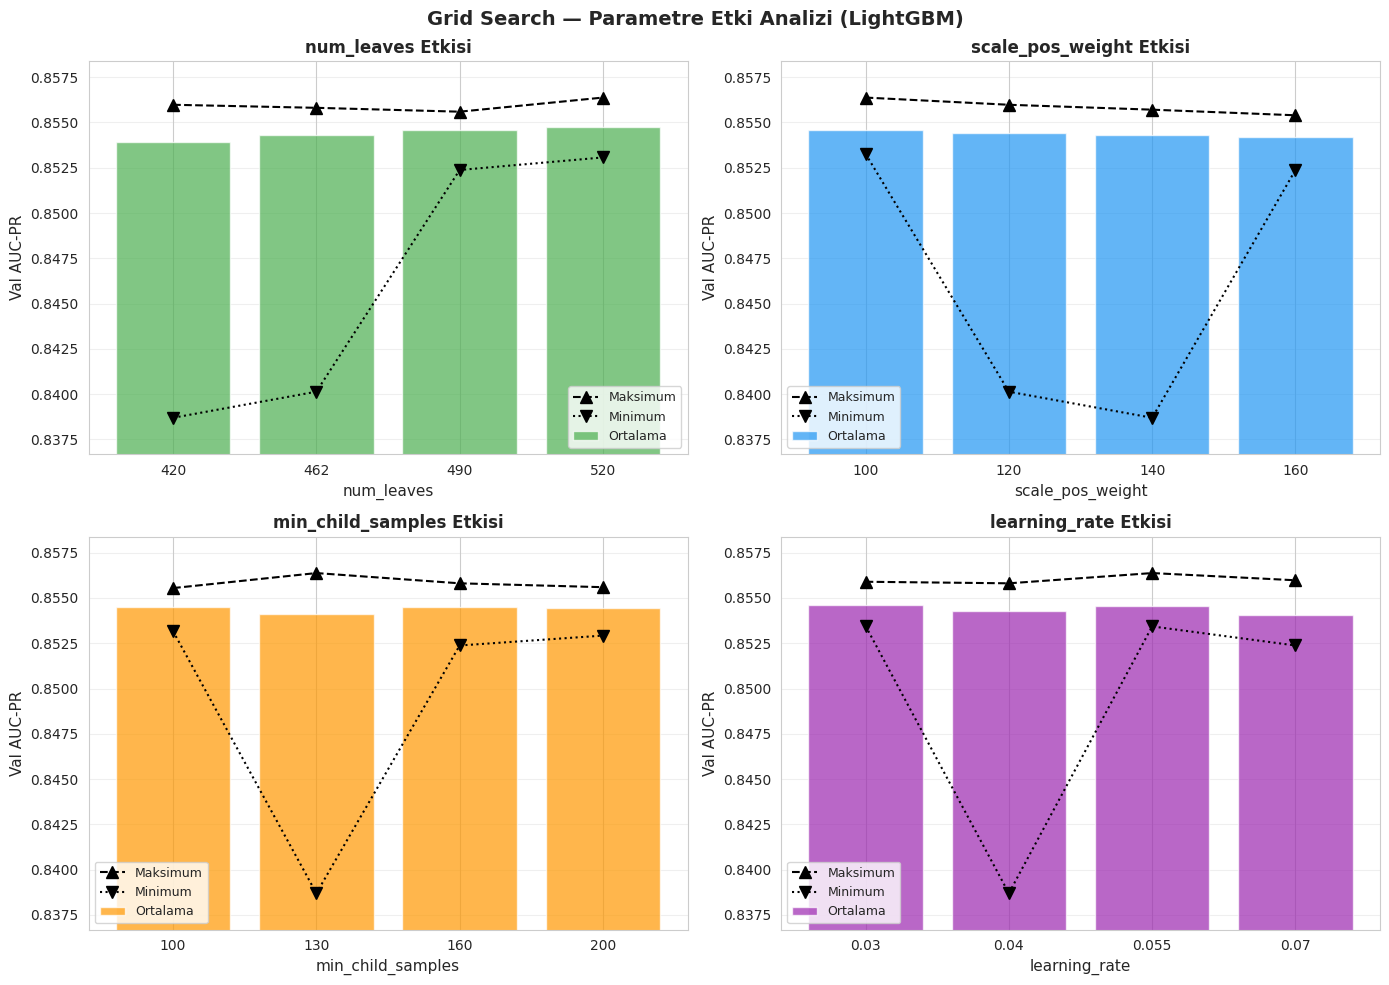

[SURE] Gorsellestirme: 1.5 sn


In [20]:
_t_start = time.time()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#4CAF50', '#2196F3', '#FF9800', '#9C27B0']

for ax_idx, (key, color) in enumerate(zip(param_keys, colors)):
    ax = axes[ax_idx]
    group = df_results.groupby(key)['val_auc_pr'].agg(['mean', 'max', 'min'])
    x_vals = group.index.tolist()
    x_pos  = range(len(x_vals))

    ax.bar(x_pos, group['mean'], color=color, alpha=0.7, label='Ortalama')
    ax.plot(x_pos, group['max'], 'k^--', markersize=8, label='Maksimum')
    ax.plot(x_pos, group['min'], 'kv:',  markersize=8, label='Minimum')
    ax.set_xticks(x_pos)
    ax.set_xticklabels([str(v) for v in x_vals])
    ax.set_xlabel(key, fontsize=11)
    ax.set_ylabel('Val AUC-PR', fontsize=11)
    ax.set_title(f'{key} Etkisi', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_ylim(df_results['val_auc_pr'].min() - 0.002,
                df_results['val_auc_pr'].max() + 0.002)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Grid Search — Parametre Etki Analizi (LightGBM)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_BASE + 'lgb_gs256_params.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'[SURE] Gorsellestirme: {time.time()-_t_start:.1f} sn')

## 21. Final LightGBM — En İyi Grid Search Parametreleriyle Eğitim

Grid Search'ün bulduğu en iyi parametrelerle final model eğitimi.
`n_estimators=3000`, `early_stopping_rounds=100` — Grid Search ile aynı ayarlar.

In [21]:
_t_start = time.time()

BEST_GS_PARAMS = {
    'scale_pos_weight'  : best_row['scale_pos_weight'],
    'num_leaves'        : int(best_row['num_leaves']),
    'min_child_samples' : int(best_row['min_child_samples']),
    'learning_rate'     : best_row['learning_rate'],
    'colsample_bytree'  : FIXED_PARAMS['colsample_bytree'],
    'reg_alpha'         : FIXED_PARAMS['reg_alpha'],
    'reg_lambda'        : FIXED_PARAMS['reg_lambda'],
    'n_estimators'      : 3000,
    'device'            : 'gpu' if USE_GPU else 'cpu',
    'objective'         : 'binary',
    'metric'            : 'average_precision',
    'boosting_type'     : 'gbdt',
    'random_state'      : 42,
    'verbose'           : -1,
    'n_jobs'            : -1,
}

print('Final LightGBM egitimi (Grid Search best params)...')
print('Parametreler:')
for k, v in BEST_GS_PARAMS.items():
    print(f'  {k:<25}: {v}')
print()

lgb_model = lgb.LGBMClassifier(**BEST_GS_PARAMS)
lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[
        lgb.early_stopping(stopping_rounds=EARLY_STOP_ROUNDS, verbose=False),
        lgb.log_evaluation(period=200),
    ],
)

elapsed_train = time.time() - _t_start
print(f'\nEgitim tamamlandi: {elapsed_train:.0f} sn | best_iteration: {lgb_model.best_iteration_}')
print(f'[SURE] Final model egitimi: {elapsed_train:.0f} sn')

Final LightGBM egitimi (Grid Search best params)...
Parametreler:
  scale_pos_weight         : 100.0
  num_leaves               : 520
  min_child_samples        : 130
  learning_rate            : 0.055
  colsample_bytree         : 0.6065
  reg_alpha                : 0.00088
  reg_lambda               : 0.2328
  n_estimators             : 3000
  device                   : gpu
  objective                : binary
  metric                   : average_precision
  boosting_type            : gbdt
  random_state             : 42
  verbose                  : -1
  n_jobs                   : -1

[200]	valid_0's average_precision: 0.839881
[400]	valid_0's average_precision: 0.847382
[600]	valid_0's average_precision: 0.85133
[800]	valid_0's average_precision: 0.852788
[1000]	valid_0's average_precision: 0.853745
[1200]	valid_0's average_precision: 0.854308
[1400]	valid_0's average_precision: 0.854573
[1600]	valid_0's average_precision: 0.8548
[1800]	valid_0's average_precision: 0.85496
[2000]	vali

## 22. Tahminler ve Metrikler

In [22]:
_t_start = time.time()

val_proba  = lgb_model.predict_proba(X_val)[:, 1]
test_proba = lgb_model.predict_proba(X_test)[:, 1]

val_auc_pr   = average_precision_score(y_val,  val_proba)
test_auc_pr  = average_precision_score(y_test, test_proba)
test_auc_roc = roc_auc_score(y_test, test_proba)

print('=' * 55)
print('  LightGBM Grid Search (NaN Native) — Sonuclar')
print('=' * 55)
print(f'  Val  AUC-PR  : {val_auc_pr:.4f}')
print(f'  Test AUC-PR  : {test_auc_pr:.4f}  (birincil metrik)')
print(f'  Test AUC-ROC : {test_auc_roc:.4f}  (ikincil metrik)')
print('=' * 55)
print(f'  Val-Test ucurumu: {val_auc_pr - test_auc_pr:+.4f}')
print(f'[SURE] Tahmin ve metrik: {time.time()-_t_start:.1f} sn')

  LightGBM Grid Search (NaN Native) — Sonuclar
  Val  AUC-PR  : 0.8555
  Test AUC-PR  : 0.6288  (birincil metrik)
  Test AUC-ROC : 0.9156  (ikincil metrik)
  Val-Test ucurumu: +0.2267
[SURE] Tahmin ve metrik: 43.2 sn


## 23. Eşik Analizi

Operasyonel hedef: **Recall ≥ 0.85** iken mümkün olan en yüksek Precision.

In [23]:
_t_start = time.time()
RECALL_TARGET = 0.85

def f_beta(prec, rec, beta=1.0):
    denom = (beta**2 * prec + rec)
    return (1 + beta**2) * prec * rec / (denom + 1e-10) if denom > 0 else 0.0

sweep_thresholds = sorted(set([
    0.001, 0.002, 0.005, 0.01, 0.02, 0.03, 0.04, 0.05,
    0.07, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40,
    0.45, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80,
    0.85, 0.90, 0.95
]))

rows_thr = []
for t in sweep_thresholds:
    y_pred = (test_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    prec = tp / (tp + fp + 1e-10)
    rec  = tp / (tp + fn + 1e-10)
    rows_thr.append({
        'Esik': t, 'Recall': rec, 'Precision': prec,
        'F1': f_beta(prec, rec, 1.0), 'F2': f_beta(prec, rec, 2.0),
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn
    })

df_thr = pd.DataFrame(rows_thr)

H = f"{'Esik':>6} {'Recall':>7} {'Prec':>7} {'F1':>6} {'F2':>6} {'TP':>5} {'FP':>6} {'FN':>5}"
SEP = '-' * len(H)
print('TEST SETI — ESIK TABLOSU (LightGBM Grid Search, NaN Native)')
print(SEP); print(H); print(SEP)
for _, r in df_thr.iterrows():
    flags = []
    if abs(r['Recall'] - 0.85) < 0.015:   flags.append('R~85')
    if abs(r['Recall'] - 0.80) < 0.015:   flags.append('R~80')
    if abs(r['Precision'] - 0.30) < 0.03: flags.append('P~30')
    flag_str = ' < ' + '+'.join(flags) if flags else ''
    print(f"{r['Esik']:>6.3f} {r['Recall']:>7.4f} {r['Precision']:>7.4f} "
          f"{r['F1']:>6.4f} {r['F2']:>6.4f} "
          f"{int(r['TP']):>5,} {int(r['FP']):>6,} {int(r['FN']):>5,}{flag_str}")
print(SEP)

def find_best_at_recall_ge(target):
    mask = df_thr['Recall'] >= target
    return df_thr[mask].sort_values('Precision', ascending=False).iloc[0] if mask.any() else None

def find_f2_optimal():
    return df_thr.sort_values('F2', ascending=False).iloc[0]

print()
print('KRITIK NOKTALAR:')
print(f'  {"Kisit":<22} {"Esik":>6} {"Recall":>7} {"Prec":>7} {"F2":>6}')
print('  ' + '-' * 52)
for label, r in [
    ('Recall >= 0.85',    find_best_at_recall_ge(0.85)),
    ('Recall >= 0.80',    find_best_at_recall_ge(0.80)),
    ('F2 Optimal',        find_f2_optimal()),
]:
    if r is None:
        print(f'  {label:<22} — ULASILAMADI')
    else:
        print(f'  {label:<22} {r["Esik"]:>6.3f} {r["Recall"]:>7.4f} {r["Precision"]:>7.4f} {r["F2"]:>6.4f}')

op_row = find_best_at_recall_ge(RECALL_TARGET)
if op_row is not None:
    print()
    print(f'Operasyonel Precision @Recall>=85%: {op_row["Precision"]:.4f}')
print(f'[SURE] Esik analizi: {time.time()-_t_start:.1f} sn')

TEST SETI — ESIK TABLOSU (LightGBM Grid Search, NaN Native)
-------------------------------------------------------
  Esik  Recall    Prec     F1     F2    TP     FP    FN
-------------------------------------------------------
 0.001  0.7060  0.3225 0.4427 0.5703 2,869  6,027 1,195 < P~30
 0.002  0.6764  0.3686 0.4772 0.5796 2,749  4,708 1,315
 0.005  0.6415  0.4378 0.5204 0.5869 2,607  3,348 1,457
 0.010  0.6228  0.4866 0.5464 0.5898 2,531  2,670 1,533
 0.020  0.6038  0.5336 0.5665 0.5883 2,454  2,145 1,610
 0.030  0.5940  0.5613 0.5772 0.5871 2,414  1,887 1,650
 0.040  0.5861  0.5817 0.5839 0.5852 2,382  1,713 1,682
 0.050  0.5800  0.5954 0.5876 0.5830 2,357  1,602 1,707
 0.070  0.5704  0.6127 0.5908 0.5784 2,318  1,465 1,746
 0.100  0.5615  0.6325 0.5949 0.5744 2,282  1,326 1,782
 0.150  0.5529  0.6570 0.6005 0.5710 2,247  1,173 1,817
 0.200  0.5475  0.6817 0.6073 0.5699 2,225  1,039 1,839
 0.250  0.5411  0.6961 0.6089 0.5663 2,199    960 1,865
 0.300  0.5357  0.7100 0.6107 0.5633 

## 24. Precision-Recall Eğrisi

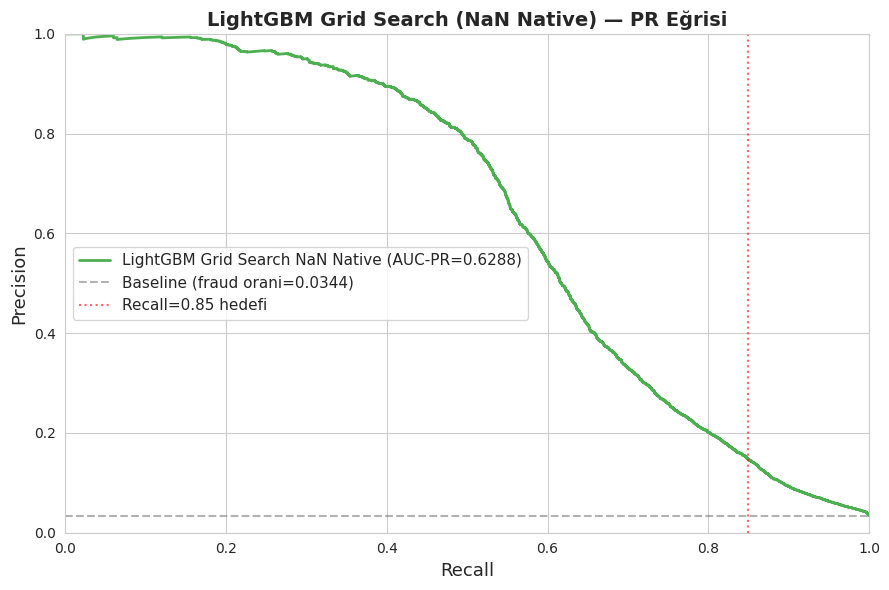

[SURE] PR egrisi: 1.0 sn


In [24]:
_t_start = time.time()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_proba)
baseline_pr = y_test.mean()

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(recall_curve, precision_curve, lw=2, color='#4CAF50',
        label=f'LightGBM Grid Search NaN Native (AUC-PR={test_auc_pr:.4f})')
ax.axhline(y=baseline_pr, color='gray', linestyle='--', alpha=0.6,
           label=f'Baseline (fraud orani={baseline_pr:.4f})')
ax.axvline(x=0.85, color='red', linestyle=':', alpha=0.6, label='Recall=0.85 hedefi')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('LightGBM Grid Search (NaN Native) — PR Eğrisi', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig(SAVE_BASE + 'lgb_gs256_pr_curve.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'[SURE] PR egrisi: {time.time()-_t_start:.1f} sn')

## 25. Özellik Önemi (Top 30)

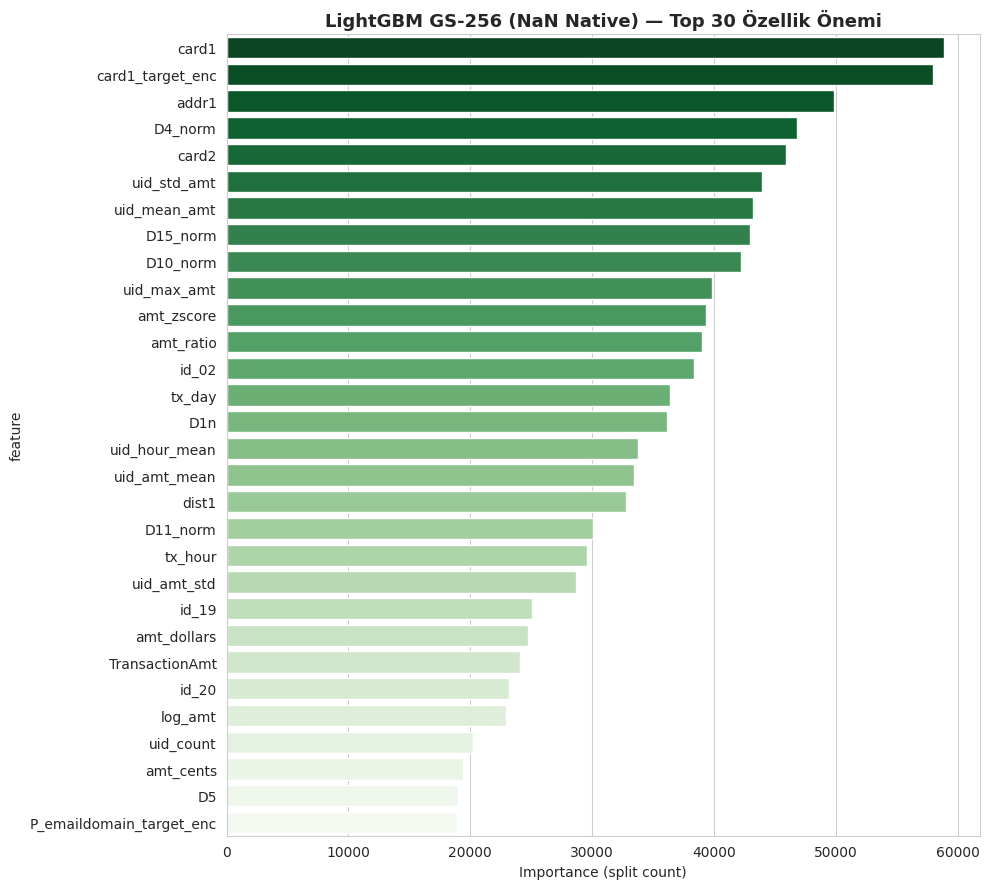

  lgb_gs256_feature_importance.csv kaydedildi.
[SURE] Ozellik onemi: 0.8 sn


In [25]:
_t_start = time.time()

feat_imp = pd.DataFrame({
    'feature'   : X_tr.columns.tolist(),
    'importance': lgb_model.feature_importances_,
}).sort_values('importance', ascending=False)

# Top 30 grafik
fig, ax = plt.subplots(figsize=(10, 9))
sns.barplot(data=feat_imp.head(30), x='importance', y='feature', palette='Greens_r', ax=ax)
ax.set_title('LightGBM GS-256 (NaN Native) — Top 30 Özellik Önemi', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (split count)')
plt.tight_layout()
plt.savefig(SAVE_BASE + 'lgb_gs256_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Tez tablosu için tüm feature importance CSV olarak kaydet
feat_imp.to_csv(SAVE_BASE + 'lgb_gs256_feature_importance.csv', index=False)
print('  lgb_gs256_feature_importance.csv kaydedildi.')
print(f'[SURE] Ozellik onemi: {time.time()-_t_start:.1f} sn')

## 26. Model ve Veri Kaydı — Drive'a Kaydetme

Tüm çıktılar `SAVE_BASE` klasörüne **lgb_gs256_** ön ekiyle kaydedilir.

| Dosya | İçerik |
|-------|--------|
| `lgb_gs256_model.pkl` | Final LightGBM modeli (best GS params) |
| `lgb_gs256_results.csv` | 256 kombinasyonun tümü (val AUC-PR, best_iter) |
| `lgb_gs256_checkpoint.csv` | Colab restart için checkpoint (GS döngüsü sırasında yazılır) |
| `lgb_gs256_threshold_table.csv` | Eşik analizi tablosu |
| `lgb_gs256_record.csv` | Tek satırlık özet — tez karşılaştırma tablosu için |
| `lgb_gs256_feature_importance.csv` | Tüm feature importance değerleri |
| `lgb_gs256_params.png` | Parametre etki analizi görseli |
| `lgb_gs256_pr_curve.png` | PR eğrisi görseli |
| `lgb_gs256_feature_importance.png` | Top-30 feature importance görseli |

In [26]:
_t_start = time.time()

import joblib, datetime

os.makedirs(SAVE_BASE, exist_ok=True)

# ── Model ─────────────────────────────────────────────────────────────────────
joblib.dump(lgb_model, SAVE_BASE + 'lgb_gs256_model.pkl')
print('  lgb_gs256_model.pkl          kaydedildi.')

# ── Tam grid sonuçları (256 satır) ───────────────────────────────────────────
df_results.to_csv(SAVE_BASE + 'lgb_gs256_results.csv', index=False)
print('  lgb_gs256_results.csv        kaydedildi.')

# ── Eşik tablosu ─────────────────────────────────────────────────────────────
df_thr.to_csv(SAVE_BASE + 'lgb_gs256_threshold_table.csv', index=False)
print('  lgb_gs256_threshold_table.csv kaydedildi.')

# ── Toplam notebook süresi ───────────────────────────────────────────────────
total_elapsed_sec = time.time() - _t0_total

# ── Özet kayıt (tez karşılaştırma tablosu için) ───────────────────────────────
f2_row = df_thr.sort_values('F2', ascending=False).iloc[0]

record = {
    # Kimlik
    'tarih'                  : datetime.datetime.now().strftime('%Y-%m-%d %H:%M'),
    'model'                  : 'LightGBM',
    'yontem'                 : f'Grid Search ({N_COMBOS} combo)',
    'nan_stratejisi'         : 'NaN Native',
    'eval_metric'            : 'average_precision (native)',
    # Grid Search
    'n_combos'               : N_COMBOS,
    'gridsearch_sure_dk'     : round(elapsed_grid / 60, 1),   # Sadece GS dongusunun suresi
    'total_sure_dk'          : round(total_elapsed_sec / 60, 1),  # Notebook basından sona
    # Model kalitesi
    'best_iteration'         : lgb_model.best_iteration_,
    'val_auc_pr'             : round(val_auc_pr, 4),
    'test_auc_pr'            : round(test_auc_pr, 4),
    'test_auc_roc'           : round(test_auc_roc, 4),
    'val_test_gap'           : round(val_auc_pr - test_auc_pr, 4),
    # Eşik analizi
    'prec_at_recall85'       : round(op_row['Precision'], 4) if op_row is not None else None,
    'recall_at_recall85'     : round(op_row['Recall'],    4) if op_row is not None else None,
    'f1_at_recall85'         : round(op_row['F1'],        4) if op_row is not None else None,
    'f2_at_recall85'         : round(op_row['F2'],        4) if op_row is not None else None,
    'thr_at_recall85'        : round(op_row['Esik'],      4) if op_row is not None else None,
    'f2_optimal_esik'        : round(f2_row['Esik'],      4),
    'f2_optimal_val'         : round(f2_row['F2'],        4),
    'f2_optimal_recall'      : round(f2_row['Recall'],    4),
    'f2_optimal_prec'        : round(f2_row['Precision'], 4),
    # En iyi parametreler
    'best_scale_pos_weight'  : int(best_row['scale_pos_weight']),
    'best_num_leaves'        : int(best_row['num_leaves']),
    'best_min_child_samples' : int(best_row['min_child_samples']),
    'best_learning_rate'     : round(best_row['learning_rate'], 4),
    # Sabit parametreler (tez için)
    'fixed_colsample_bytree' : FIXED_PARAMS['colsample_bytree'],
    'fixed_reg_alpha'        : FIXED_PARAMS['reg_alpha'],
    'fixed_reg_lambda'       : FIXED_PARAMS['reg_lambda'],
}

df_record = pd.DataFrame([record])
record_path = SAVE_BASE + 'lgb_gs256_record.csv'
df_record.to_csv(record_path, index=False)
print('  lgb_gs256_record.csv         kaydedildi.')

print()
print('=== VERİ KAYDI (lgb_gs256_record.csv) ===')
for k, v in record.items():
    print(f'  {k:<30}: {v}')

print(f'\n[SURE] Model ve veri kaydetme: {time.time()-_t_start:.1f} sn')

  lgb_gs256_model.pkl          kaydedildi.
  lgb_gs256_results.csv        kaydedildi.
  lgb_gs256_threshold_table.csv kaydedildi.
  lgb_gs256_record.csv         kaydedildi.

=== VERİ KAYDI (lgb_gs256_record.csv) ===
  tarih                         : 2026-05-18 00:45
  model                         : LightGBM
  yontem                        : Grid Search (256 combo)
  nan_stratejisi                : NaN Native
  eval_metric                   : average_precision (native)
  n_combos                      : 256
  gridsearch_sure_dk            : 1745.7
  total_sure_dk                 : 330.0
  best_iteration                : 2958
  val_auc_pr                    : 0.8555
  test_auc_pr                   : 0.6288
  test_auc_roc                  : 0.9156
  val_test_gap                  : 0.2267
  prec_at_recall85              : None
  recall_at_recall85            : None
  f1_at_recall85                : None
  f2_at_recall85                : None
  thr_at_recall85               : None
  f2_opti

## 27. Deney Özeti ve Karşılaştırma

In [27]:
print('=' * 70)
print('  DENEY ÖZETİ — LightGBM Grid Search 256-combo (NaN Native)')
print('=' * 70)
print(f'  Model              : LightGBM (GBDT, NaN Native)')
print(f'  Yontem             : Grid Search — 4x4x4x4 = 256 kombinasyon')
print()
print(f'  SURE:')
print(f'    Grid Search dongusu   : {elapsed_grid/60:.1f} dakika')
print(f'    Notebook toplam       : {total_elapsed_sec/60:.1f} dakika')
print()
print(f'  EN IYI PARAMETRELER (val AUC-PR bazinda):')
for k in param_keys:
    print(f'    {k:<25}: {best_row[k]}')
print(f'    {"best_iteration":<25}: {lgb_model.best_iteration_}')
print(f'    {"colsample_bytree":<25}: {FIXED_PARAMS["colsample_bytree"]} (sabit)')
print(f'    {"reg_alpha":<25}: {FIXED_PARAMS["reg_alpha"]} (sabit)')
print(f'    {"reg_lambda":<25}: {FIXED_PARAMS["reg_lambda"]} (sabit)')
print()
print(f'  METRIKLER:')
print(f'    Val  AUC-PR        : {best_row["val_auc_pr"]:.4f}')
print(f'    Test AUC-PR        : {test_auc_pr:.4f}  <- birincil metrik')
print(f'    Test AUC-ROC       : {test_auc_roc:.4f}')
print(f'    Val-Test fark      : {val_auc_pr - test_auc_pr:+.4f}')
if op_row is not None:
    print(f'    Prec @Recall>=85%  : {op_row["Precision"]:.4f}  (esik={op_row["Esik"]:.3f})')
    print(f'    F2  @Recall>=85%   : {op_row["F2"]:.4f}')
else:
    print(f'    Recall>=85%        : ULASILAMADI')
print()
print('  KARSILASTIRMA (LightGBM — tum yontemler):')
print(f'  {"Yontem":<35} {"Val AUC-PR":>10} {"Test AUC-PR":>12} {"Test ROC":>10}')
print('  ' + '-' * 72)
print(f'  {"LGB GS 256-combo (bu calisma)":<35} {best_row["val_auc_pr"]:>10.4f} {test_auc_pr:>12.4f} {test_auc_roc:>10.4f}')
print(f'  {"LGB GS 32-combo (onceki)":<35} {"0.8555":>10} {"0.6312":>12} {"0.9179":>10}')
print(f'  {"LGB Optuna V2 (AUC-PR hedefli)":<35} {"0.8559":>10} {"0.6307":>12} {"0.9179":>10}')
print()
print(f'  Kaydedilen dosyalar (15-Mayis-Cuma/):')
print(f'    lgb_gs256_model.pkl')
print(f'    lgb_gs256_results.csv')
print(f'    lgb_gs256_record.csv')
print(f'    lgb_gs256_threshold_table.csv')
print(f'    lgb_gs256_feature_importance.csv')
print(f'    lgb_gs256_params.png')
print(f'    lgb_gs256_pr_curve.png')
print(f'    lgb_gs256_feature_importance.png')
print('=' * 70)

  DENEY ÖZETİ — LightGBM Grid Search 256-combo (NaN Native)
  Model              : LightGBM (GBDT, NaN Native)
  Yontem             : Grid Search — 4x4x4x4 = 256 kombinasyon

  SURE:
    Grid Search dongusu   : 1745.7 dakika
    Notebook toplam       : 330.0 dakika

  EN IYI PARAMETRELER (val AUC-PR bazinda):
    num_leaves               : 520.0
    scale_pos_weight         : 100.0
    min_child_samples        : 130.0
    learning_rate            : 0.055
    best_iteration           : 2958
    colsample_bytree         : 0.6065 (sabit)
    reg_alpha                : 0.00088 (sabit)
    reg_lambda               : 0.2328 (sabit)

  METRIKLER:
    Val  AUC-PR        : 0.8564
    Test AUC-PR        : 0.6288  <- birincil metrik
    Test AUC-ROC       : 0.9156
    Val-Test fark      : +0.2267
    Recall>=85%        : ULASILAMADI

  KARSILASTIRMA (LightGBM — tum yontemler):
  Yontem                              Val AUC-PR  Test AUC-PR   Test ROC
  ----------------------------------------------